In [1]:
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt

In [3]:
## Get the number of occurence of each resistance genes

sparqlQuery = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?gene_name (COUNT(?gene_name) AS ?nb_resistance_genes)
FROM <http://www.ontotext.com/explicit>
WHERE {
    ?sample rdf:type sio:001050 .

    ?observableProperty rdf:type sosa:ObservableProperty ;
        rdfs:label 'Resistance gene' .

    ?observation sosa:observedProperty ?observableProperty ;
        sio:000332 ?sample ;
        sosa:hasFeatureOfInterest ?gene .

    ?gene rdf:type ncit:C16612 ;
          rdf:type [ rdfs:subClassOf+ aro:3000000 ] ;
        rdfs:label ?gene_name .

}
GROUP BY ?gene_name 
ORDER BY DESC(?nb_resistance_genes)
"""

In [4]:
## Defining a data structure for the plot
data = {
    "gene_name": [],
    "nb_resistance_genes": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("http://localhost:8081/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery)
try:
    res = sparql.query().convert()
    recs = res["results"]["bindings"]
    for item in recs:
        data["gene_name"].append(item["gene_name"]["value"])
        data["nb_resistance_genes"].append(int(item["nb_resistance_genes"]["value"]))
except Exception as e:
    print(e)

In [5]:
df = pd.DataFrame(data)
df

,gene_name,nb_resistance_genes
0,ADC-25,83
1,sul1,27
2,sul2,26
3,floR,20
4,ant(2'')-Ia,18
...,...,...
125,catB8,1
126,cfxA3,1
127,mcr-3.10,1
128,aac(6')-Ib-Hangzhou,1


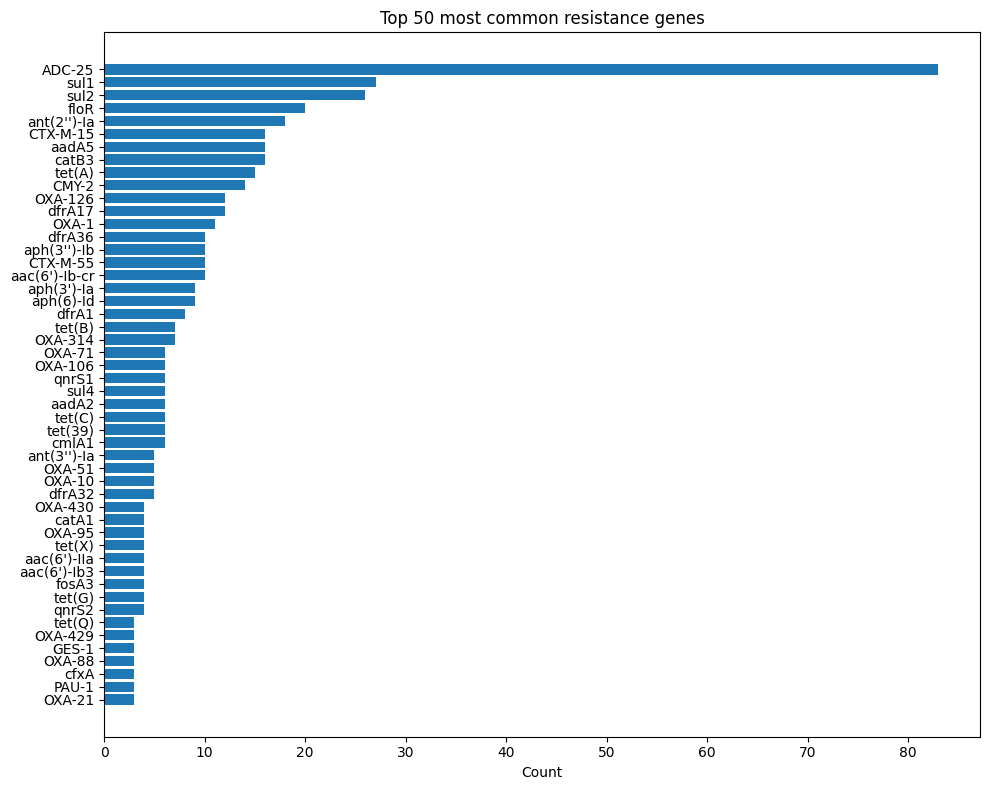

In [20]:
df = df.sort_values("nb_resistance_genes")

top50 = df.nlargest(50, "nb_resistance_genes").sort_values("nb_resistance_genes")

plt.figure(figsize=(10, 8))
plt.barh(top50["gene_name"], top50["nb_resistance_genes"])
plt.xlabel("Count")
plt.title("Top 50 most common resistance genes")
plt.tight_layout()
plt.show()

In [21]:
## Get the number of samples having each number of a resistance genes

sparqlQuery2 = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?geneCount (COUNT(?sample) AS ?sampleCount)
FROM <http://www.ontotext.com/explicit>
WHERE {
  {
    SELECT ?sample (COUNT(DISTINCT ?gene) AS ?geneCount)
    WHERE {
      ?sample rdf:type sio:001050 .

    ?observableProperty rdf:type sosa:ObservableProperty ;
        rdfs:label 'Resistance gene' .

    ?observation sosa:observedProperty ?observableProperty ;
        sio:000332 ?sample ;
        sosa:hasFeatureOfInterest ?gene .

    ?gene rdf:type ncit:C16612 ;
          rdf:type [ rdfs:subClassOf+ aro:3000000 ] ;
        rdfs:label ?gene_name .
    }
    GROUP BY ?sample
  }
}
GROUP BY ?geneCount
ORDER BY ?geneCount
"""

In [25]:
## Defining a data structure for the plot
data2 = {
    "geneCount": [],
    "sampleCount": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("http://localhost:8081/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery2)
try:
    res2 = sparql.query().convert()
    recs2 = res2["results"]["bindings"]
    for item in recs2:
        data2["geneCount"].append(item["geneCount"]["value"])
        data2["sampleCount"].append(int(item["sampleCount"]["value"]))
except Exception as e:
    print(e)

In [26]:
df2 = pd.DataFrame(data2)
df2

,geneCount,sampleCount
0,1,4
1,2,82
2,3,1
3,4,1
4,5,1
5,6,4
6,7,1
7,8,2
8,10,1
9,11,6


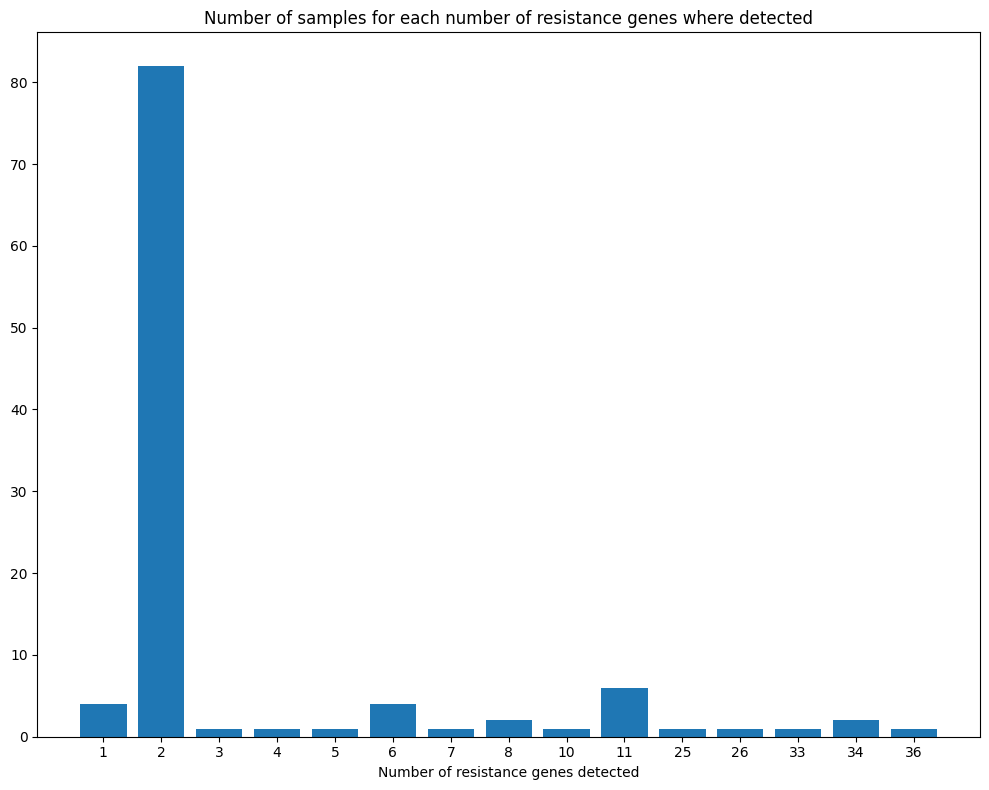

In [28]:
plt.figure(figsize=(10, 8))
plt.bar(df2["geneCount"], df2["sampleCount"])
plt.xlabel("Number of resistance genes detected")
plt.title("Number of samples for each number of resistance genes where detected")
plt.tight_layout()
plt.show()